In [67]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

In [68]:
import nltk
nltk.download('wordnet')
nltk.download("omw-1.4")

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

##Step 1
From the WordNet database take the synset 'search.v.01'. Extract lemmas that belong to the synset for all the languages of the database.

In [69]:
from nltk.corpus import wordnet as wn
wn.add_omw()


In [70]:
syn = wn.synset("search.v.01")
syn

Synset('search.v.01')

In [71]:
langs = wn.langs()
len(langs)

62

In [72]:
lemmas_by_lang = {}

for lang in langs:
    lemmas = [l.name() for l in syn.lemmas(lang=lang)]
    if lemmas:  # сохраняем только непустые
        lemmas_by_lang[lang] = sorted(set(lemmas))

len(lemmas_by_lang)


57

In [73]:
pretty_lemmas_by_lang = {
    lang: [lemma.replace("_", " ") for lemma in lemmas]
    for lang, lemmas in lemmas_by_lang.items()
}
for lang, lemmas in sorted(pretty_lemmas_by_lang.items()):
    print(lang, ":", ", ".join(lemmas))


als : gjurmim, kërkim, kërkoj
als_als : gjurmim, kërkim, kërkoj
arb : استشار, استكشف, اكتشف, بحث, بحث في, تقصى, حاول, حاول إيجاد, سبر, سعى لعمل شئ, طلب, طمح في, فتش, فحص, قصد
arb_arb : استشار, استكشف, اكتشف, بحث, بحث في, تقصى, حاول, حاول إيجاد, سبر, سعى لعمل شئ, طلب, طمح في, فتش, فحص, قصد
bul : търся
bul_bul : търся
cat : buscar, cercar, escorcollar
cat_mcr : buscar, cercar, escorcollar
cmn : 寻找, 寻觅, 找, 找寻, 搜寻, 搜查, 搜索
cmn_cow : 寻找, 寻觅, 找, 找寻, 搜寻, 搜查, 搜索
dan : lede, søge
dan_dan : lede, søge
ell : ψάχνω
ell_ell : ψάχνω
eng : look for, search, seek
eus : arakatu, erregistratu, miatu
eus_mcr : arakatu, erregistratu, miatu
fin : etsiä
fin_fin : etsiä
fra : chercher, rechercher
fra_fra : chercher, rechercher
glg : buscar, explorar, rexistrar
glg_mcr : buscar, explorar, rexistrar
heb : חִפֵּשׂ
heb_heb : חִפֵּשׂ
hrv : potražiti, pretražiti, pretraživati, tragati, tražiti
hrv_hrv : potražiti, pretražiti, pretraživati, tragati, tražiti
ind : cari, geledah, memeriksa, mencari, mengacar, mengemon

##Step 2

For each lemma of each language create a list of synsets that that lemma belongs to. Leave only synsets that have more than 3 lemmas from our original list. Those synsets will become the nodes of our graph.

In [74]:
lemma2synsets = {}

for lang, lemmas in lemmas_by_lang.items():
    for lemma in lemmas:
        lemma2synsets[(lang, lemma)] = wn.synsets(lemma, lang=lang)

len(lemma2synsets)


207

In [75]:
(lang0, lemma0), synsets0 = next(iter(lemma2synsets.items()))
lang0, lemma0, [s.name() for s in synsets0[:5]]

('eng', 'look_for', ['search.v.01', 'anticipate.v.05'])

In [76]:
synset_support = {}  # Synset -> set of (lang, lemma)

for key, synsets in lemma2synsets.items():
    for s in synsets:
        synset_support.setdefault(s, set()).add(key)

len(synset_support)
print(synset_support)


{Synset('search.v.01'): {('ind', 'menggeledah'), ('fra', 'chercher'), ('hrv', 'potražiti'), ('tha', 'ค้นหา'), ('cat_mcr', 'escorcollar'), ('zsm_msa', 'mencari'), ('arb', 'حاول_إيجاد'), ('cat_mcr', 'cercar'), ('dan_dan', 'lede'), ('jpn', '探す'), ('ita_ita', 'cercare'), ('cmn_cow', '找'), ('ind', 'merunjang'), ('arb_arb', 'تقصى'), ('jpn_jpn', '探しまわる'), ('ind_msa', 'merisik'), ('ind', 'merosok'), ('ell_ell', 'ψάχνω'), ('heb_heb', 'חִפֵּשׂ'), ('ita', 'cercare'), ('glg_mcr', 'explorar'), ('eus_mcr', 'miatu'), ('arb', 'حاول'), ('arb', 'طلب'), ('ind_msa', 'memeriksa'), ('glg', 'rexistrar'), ('jpn_jpn', '捜し求める'), ('hrv_hrv', 'tragati'), ('jpn_jpn', '探しもとめる'), ('arb', 'استكشف'), ('ell', 'ψάχνω'), ('nno_nor', 'søke'), ('als', 'kërkim'), ('arb', 'بحث'), ('arb_arb', 'طمح_في'), ('arb_arb', 'بحث_في'), ('dan_dan', 'søge'), ('zsm', 'merunjang'), ('hrv_hrv', 'pretražiti'), ('ind', 'mengacar'), ('por_por', 'buscar'), ('nld_nld', 'rondzien'), ('ind', 'cari'), ('als', 'kërkoj'), ('zsm_msa', 'meraba-raba'), 

In [79]:
selected_synsets = sorted(
    [s for s, keys in synset_support.items() if len(keys) > 3],
    key=lambda s: s.name()
)
print(len(selected_synsets))
print(selected_synsets[:5])


159
[Synset('aim.v.06'), Synset('analyze.v.01'), Synset('anticipate.v.05'), Synset('ask.v.02'), Synset('ask.v.03')]


In [80]:
selected_sorted = sorted(selected_synsets, key=lambda s: len(synset_support[s]), reverse=True)

for s in selected_sorted[:10]:
    print(s.name(), len(synset_support[s]), "-", s.definition())


search.v.01 207 - try to locate or discover, or try to establish the existence of
search.v.02 103 - search or seek
search.v.04 65 - subject to a search
research.v.02 51 - inquire into
seek.v.01 37 - try to get or reach
try.v.01 25 - make an effort or attempt
comb.v.02 18 - search thoroughly
inspect.v.01 18 - look over carefully
probe.v.01 16 - question or examine thoroughly and closely
search.n.02 15 - an investigation seeking answers


##Step 3

Now let's define the edges. Put an edge between two synsets if there is at least one language where a lemma belongs to both synsets. We'll draw a weighted graph: the weight of an edge will represent the number of lemmas that belong to both nodes.

In [81]:
selected_set = set(selected_synsets)


In [83]:
synset2lemmas = {}

for s in selected_synsets:
    L = set()
    for lang in wn.langs():
        for l in s.lemmas(lang=lang):
            L.add((lang, l.name()))
    synset2lemmas[s] = L

# sanity check
some = selected_synsets[0]
len(synset2lemmas[some])
print(synset2lemmas[some])


{('jpn', '目指す'), ('zsm_msa', 'membidikkan'), ('tha_tha', 'มุ่ง'), ('hrv_hrv', 'aludirati'), ('zsm', 'membega'), ('ind_msa', 'menenang'), ('ind_msa', 'membidik'), ('fin', 'pyrkiä'), ('fin', 'aikoa'), ('arb', 'حاول'), ('hrv_hrv', 'misliti'), ('jpn_jpn', '目指す'), ('ron', 'ținti'), ('ind', 'mengacukan'), ('zsm', 'memaksudkan'), ('fra_fra', 'viser'), ('als', 'shenjestër'), ('fra', 'viser'), ('hrv', 'aludirati'), ('cmn_cow', '针对'), ('ind_msa', 'membidikkan'), ('ind', 'menenang'), ('ind', 'mengarahkan'), ('arb', 'هدف'), ('ind', 'mengacu'), ('ind', 'membidik'), ('jpn', '目差す'), ('ind_msa', 'mengarahkan'), ('arb', 'سعى'), ('zsm', 'mengacukan'), ('ind_msa', 'mengacu'), ('zsm_msa', 'membega'), ('ron_ron', 'ținti'), ('por_por', 'apontar'), ('slv_slv', 'ciljati'), ('slv', 'ciljati'), ('als_als', 'shenjestër'), ('arb', 'تاق'), ('tha', 'มุ่ง'), ('jpn_jpn', '目差す'), ('ind', 'membidikkan'), ('zsm_msa', 'memaksudkan'), ('cmn', '针对'), ('arb', 'سدد'), ('arb', 'وجه'), ('arb', 'قصد'), ('fin_fin', 'aikoa'), ('h

In [85]:
edges = {}

nodes = list(selected_synsets)

for i in range(len(nodes)):
    s1 = nodes[i]
    for j in range(i+1, len(nodes)):
        s2 = nodes[j]
        inter = synset2lemmas[s1].intersection(synset2lemmas[s2])
        w = len(inter)
        if w > 0:
            edges[(s1, s2)] = w

len(edges)


3006

In [86]:
top_edges = sorted(
    edges.items(),
    key=lambda kv: (-kv[1], kv[0][0].name(), kv[0][1].name())
)

for (s1, s2), w in top_edges[:10]:
    print(s1.name(), "<->", s2.name(), "weight=", w)


gather.v.01 <-> roll_up.v.02 weight= 143
search.v.01 <-> search.v.02 weight= 103
detect.v.01 <-> find.v.03 weight= 97
see.v.05 <-> visualize.v.01 weight= 93
detect.v.01 <-> determine.v.01 weight= 91
ask.v.04 <-> necessitate.v.01 weight= 90
detect.v.01 <-> locate.v.01 weight= 90
see.v.01 <-> see.v.05 weight= 90
control.v.01 <-> control.v.02 weight= 87
sample.v.01 <-> try.v.01 weight= 85


##Step 4

Let's analyze the graph. How many connected components do we have? What is the density? What synsets have the highest weighted degree? What nodes are central (use different methods: degree centrality, eigencentrality)? Split the graph into communities, comment upon the results.

In [87]:
import networkx as nx

G = nx.Graph()

# добавляем узлы
for s in selected_synsets:
    G.add_node(s)

# добавляем взвешенные рёбра
for (s1, s2), w in edges.items():
    G.add_edge(s1, s2, weight=w)

G.number_of_nodes(), G.number_of_edges()


(159, 3006)

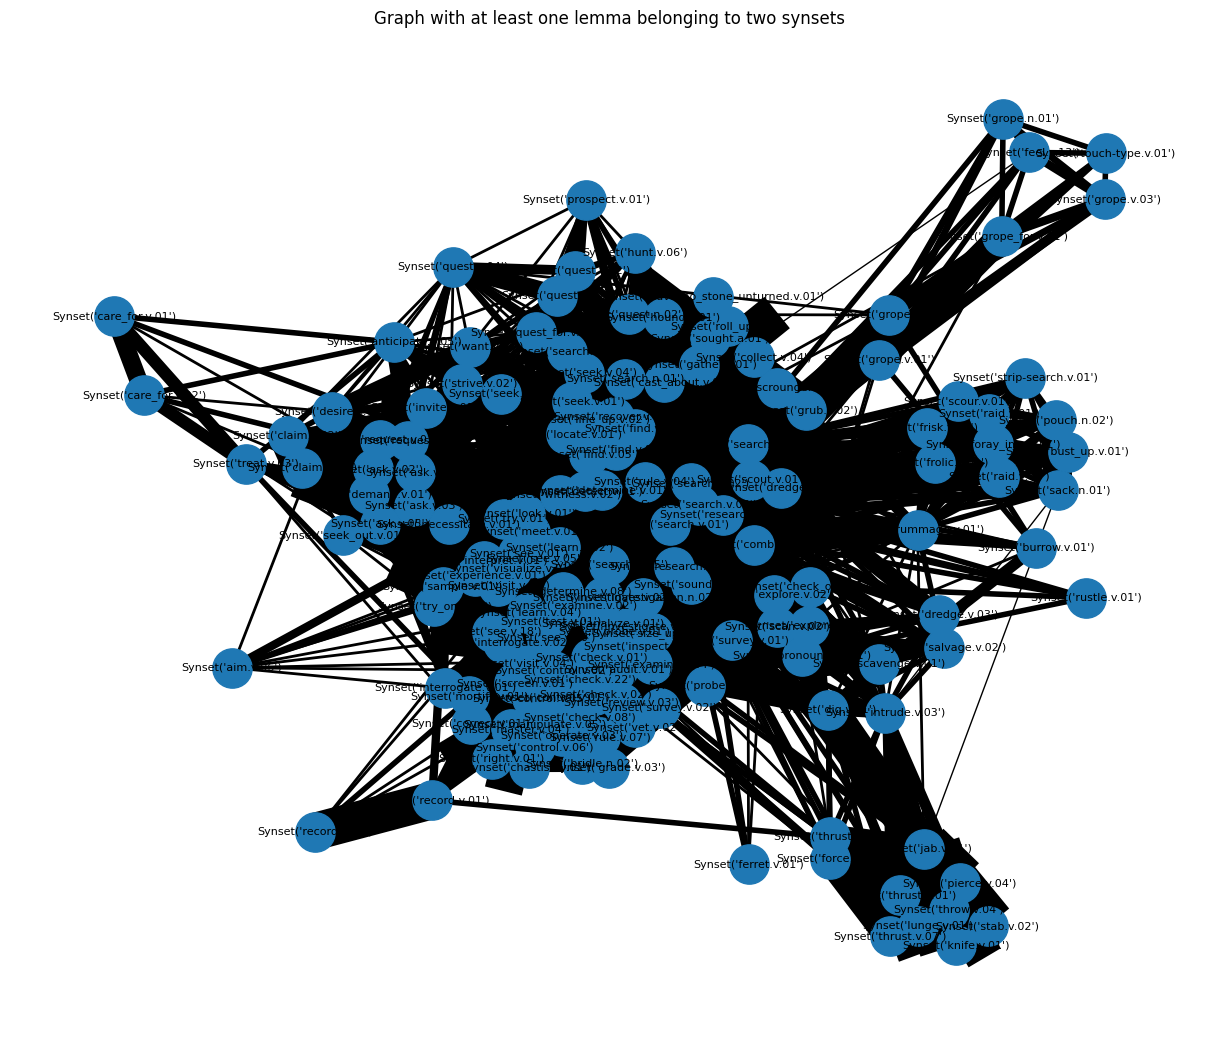

In [89]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 10))
pos = nx.spring_layout(G, k=0.3)

weights = [G[u][v]['weight'] for u, v in G.edges()]

nx.draw(G, pos,
        with_labels=True,
        node_size=800,
        font_size=8,
        width=weights)

plt.title("Graph with at least one lemma belonging to two synsets")
plt.show()

In [90]:
components = list(nx.connected_components(G))
sorted([len(c) for c in components], reverse=True)


[159]

In [91]:
print("Number of components:", len(components))

Number of components: 1


In [92]:
nx.density(G)


0.23931215667542394

Density of 0.24 means that around one fourth of possible connections between nodes is realized.

In [93]:
degree_dict = dict(G.degree())
sorted(degree_dict.items(), key=lambda x: x[1], reverse=True)[:10]


[(Synset('search.v.01'), 158),
 (Synset('search.v.02'), 112),
 (Synset('search.v.04'), 109),
 (Synset('research.v.02'), 93),
 (Synset('investigate.v.02'), 86),
 (Synset('determine.v.08'), 78),
 (Synset('analyze.v.01'), 76),
 (Synset('examine.v.02'), 75),
 (Synset('learn.v.04'), 75),
 (Synset('inspect.v.01'), 74)]

In [94]:
weighted_degree = dict(G.degree(weight='weight'))
sorted(weighted_degree.items(), key=lambda x: x[1], reverse=True)[:10]


[(Synset('examine.v.02'), 1523),
 (Synset('determine.v.08'), 1202),
 (Synset('search.v.01'), 1172),
 (Synset('see.v.10'), 1114),
 (Synset('learn.v.02'), 1080),
 (Synset('see.v.05'), 1020),
 (Synset('analyze.v.01'), 987),
 (Synset('control.v.02'), 927),
 (Synset('inspect.v.01'), 918),
 (Synset('meet.v.01'), 902)]

In [95]:
import numpy as np

deg_values = list(degree_dict.values())
wdeg_values = list(weighted_degree.values())

print("Degree:")
print("min:", np.min(deg_values))
print("max:", np.max(deg_values))
print("mean:", np.mean(deg_values))

print("\nWeighted degree:")
print("min:", np.min(wdeg_values))
print("max:", np.max(wdeg_values))
print("mean:", np.mean(wdeg_values))


Degree:
min: 4
max: 158
mean: 37.81132075471698

Weighted degree:
min: 12
max: 1523
mean: 344.49056603773585


In [99]:
deg_cent = nx.degree_centrality(G) #the more relations, the more important the node
sorted(deg_cent.items(), key=lambda x: x[1], reverse=True)[:10]


[(Synset('search.v.01'), 1.0),
 (Synset('search.v.02'), 0.7088607594936709),
 (Synset('search.v.04'), 0.689873417721519),
 (Synset('research.v.02'), 0.5886075949367089),
 (Synset('investigate.v.02'), 0.5443037974683544),
 (Synset('determine.v.08'), 0.49367088607594933),
 (Synset('analyze.v.01'), 0.4810126582278481),
 (Synset('examine.v.02'), 0.47468354430379744),
 (Synset('learn.v.04'), 0.47468354430379744),
 (Synset('inspect.v.01'), 0.46835443037974683)]

In [101]:
eig_cent = nx.eigenvector_centrality(G, weight='weight', max_iter=1000) #the more friends your neighbors have, the more important you are
sorted(eig_cent.items(), key=lambda x: x[1], reverse=True)[:10]


[(Synset('examine.v.02'), 0.3109896586649411),
 (Synset('see.v.05'), 0.27423762720631156),
 (Synset('learn.v.02'), 0.27304456103504476),
 (Synset('see.v.01'), 0.25372324899223514),
 (Synset('visualize.v.01'), 0.24707718696885717),
 (Synset('meet.v.01'), 0.2449785950351505),
 (Synset('visit.v.01'), 0.24141700208415412),
 (Synset('determine.v.08'), 0.24049575450225277),
 (Synset('interpret.v.01'), 0.21325713549205763),
 (Synset('experience.v.01'), 0.20320004535963573)]

In [100]:
close_cent = nx.closeness_centrality(G) #the more central (closer to other nodes), the more important the node
sorted(close_cent.items(), key=lambda x: x[1], reverse=True)[:10]

[(Synset('search.v.01'), 1.0),
 (Synset('search.v.02'), 0.7745098039215687),
 (Synset('search.v.04'), 0.7632850241545893),
 (Synset('research.v.02'), 0.7085201793721974),
 (Synset('investigate.v.02'), 0.6869565217391305),
 (Synset('determine.v.08'), 0.6638655462184874),
 (Synset('analyze.v.01'), 0.6583333333333333),
 (Synset('examine.v.02'), 0.6556016597510373),
 (Synset('learn.v.04'), 0.6556016597510373),
 (Synset('inspect.v.01'), 0.6528925619834711)]

In [102]:
from networkx.algorithms import community

gn_gen = community.girvan_newman(G)
gn_level1 = next(gn_gen)
gn_level2 = next(gn_gen)

print("Girvan-Newman level 1 sizes:", sorted([len(c) for c in gn_level1], reverse=True))
print("Girvan-Newman level 2 sizes:", sorted([len(c) for c in gn_level2], reverse=True))


Girvan-Newman level 1 sizes: [153, 6]
Girvan-Newman level 2 sizes: [143, 10, 6]


In [103]:
com_greedy = list(community.greedy_modularity_communities(G, weight="weight"))
print("Greedy modularity: #communities =", len(com_greedy))
print("Sizes:", sorted([len(c) for c in com_greedy], reverse=True))


Greedy modularity: #communities = 8
Sizes: [60, 41, 23, 13, 12, 5, 3, 2]


In [104]:
def describe_community(comm, k=10):
    sub = G.subgraph(list(comm))
    wdeg_sub = dict(sub.degree(weight="weight"))
    top = sorted(wdeg_sub, key=wdeg_sub.get, reverse=True)[:k]
    for s in top:
        print(s.name(), "wdeg_in_comm=", wdeg_sub[s], "-", s.definition())


In [105]:
com_sorted = sorted(com_greedy, key=len, reverse=True)

for i in range(min(3, len(com_sorted))):
    print("\nCommunity", i, "size =", len(com_sorted[i]))
    describe_community(com_sorted[i], k=10)



Community 0 size = 60
search.v.01 wdeg_in_comm= 626 - try to locate or discover, or try to establish the existence of
search.v.02 wdeg_in_comm= 540 - search or seek
research.v.02 wdeg_in_comm= 460 - inquire into
search.v.04 wdeg_in_comm= 352 - subject to a search
seek.v.01 wdeg_in_comm= 239 - try to get or reach
search.n.02 wdeg_in_comm= 216 - an investigation seeking answers
comb.v.02 wdeg_in_comm= 164 - search thoroughly
search.n.01 wdeg_in_comm= 152 - the activity of looking thoroughly in order to find something or someone
dredge.v.02 wdeg_in_comm= 127 - search (as the bottom of a body of water) for something valuable or lost
quest.n.02 wdeg_in_comm= 119 - the act of searching for something

Community 1 size = 41
control.v.02 wdeg_in_comm= 794 - lessen the intensity of; temper; hold in restraint; hold or keep within limits
see.v.10 wdeg_in_comm= 699 - be careful or certain to do something; make certain of something
control.v.05 wdeg_in_comm= 687 - check or regulate (a scientific ex

##Step 5

Draw a graph similar to the one in Step 3, but put an edge only in cases where there are at least 5 lemmas that belong to two synsets. We are now looking for more stable colexifications. Analyze the new graph (as outlined in Step 4). Compare the graph from Steps 3 and 4 with the new graph. What has changed? Which of the two graphs seems more interesting to you and why?

In [106]:
import networkx as nx

THRESH = 5

G5 = nx.Graph()
G5.add_nodes_from(G.nodes())

for u, v, data in G.edges(data=True):
    w = data.get("weight", 1)
    if w >= THRESH:
        G5.add_edge(u, v, weight=w)

isolates = list(nx.isolates(G5))
G5_noiso = G5.copy()
G5_noiso.remove_nodes_from(isolates)

print("G5 nodes/edges:", G5.number_of_nodes(), G5.number_of_edges())
print("isolates:", len(isolates))
print("G5_noiso nodes/edges:", G5_noiso.number_of_nodes(), G5_noiso.number_of_edges())

G5 nodes/edges: 159 1212
isolates: 8
G5_noiso nodes/edges: 151 1212


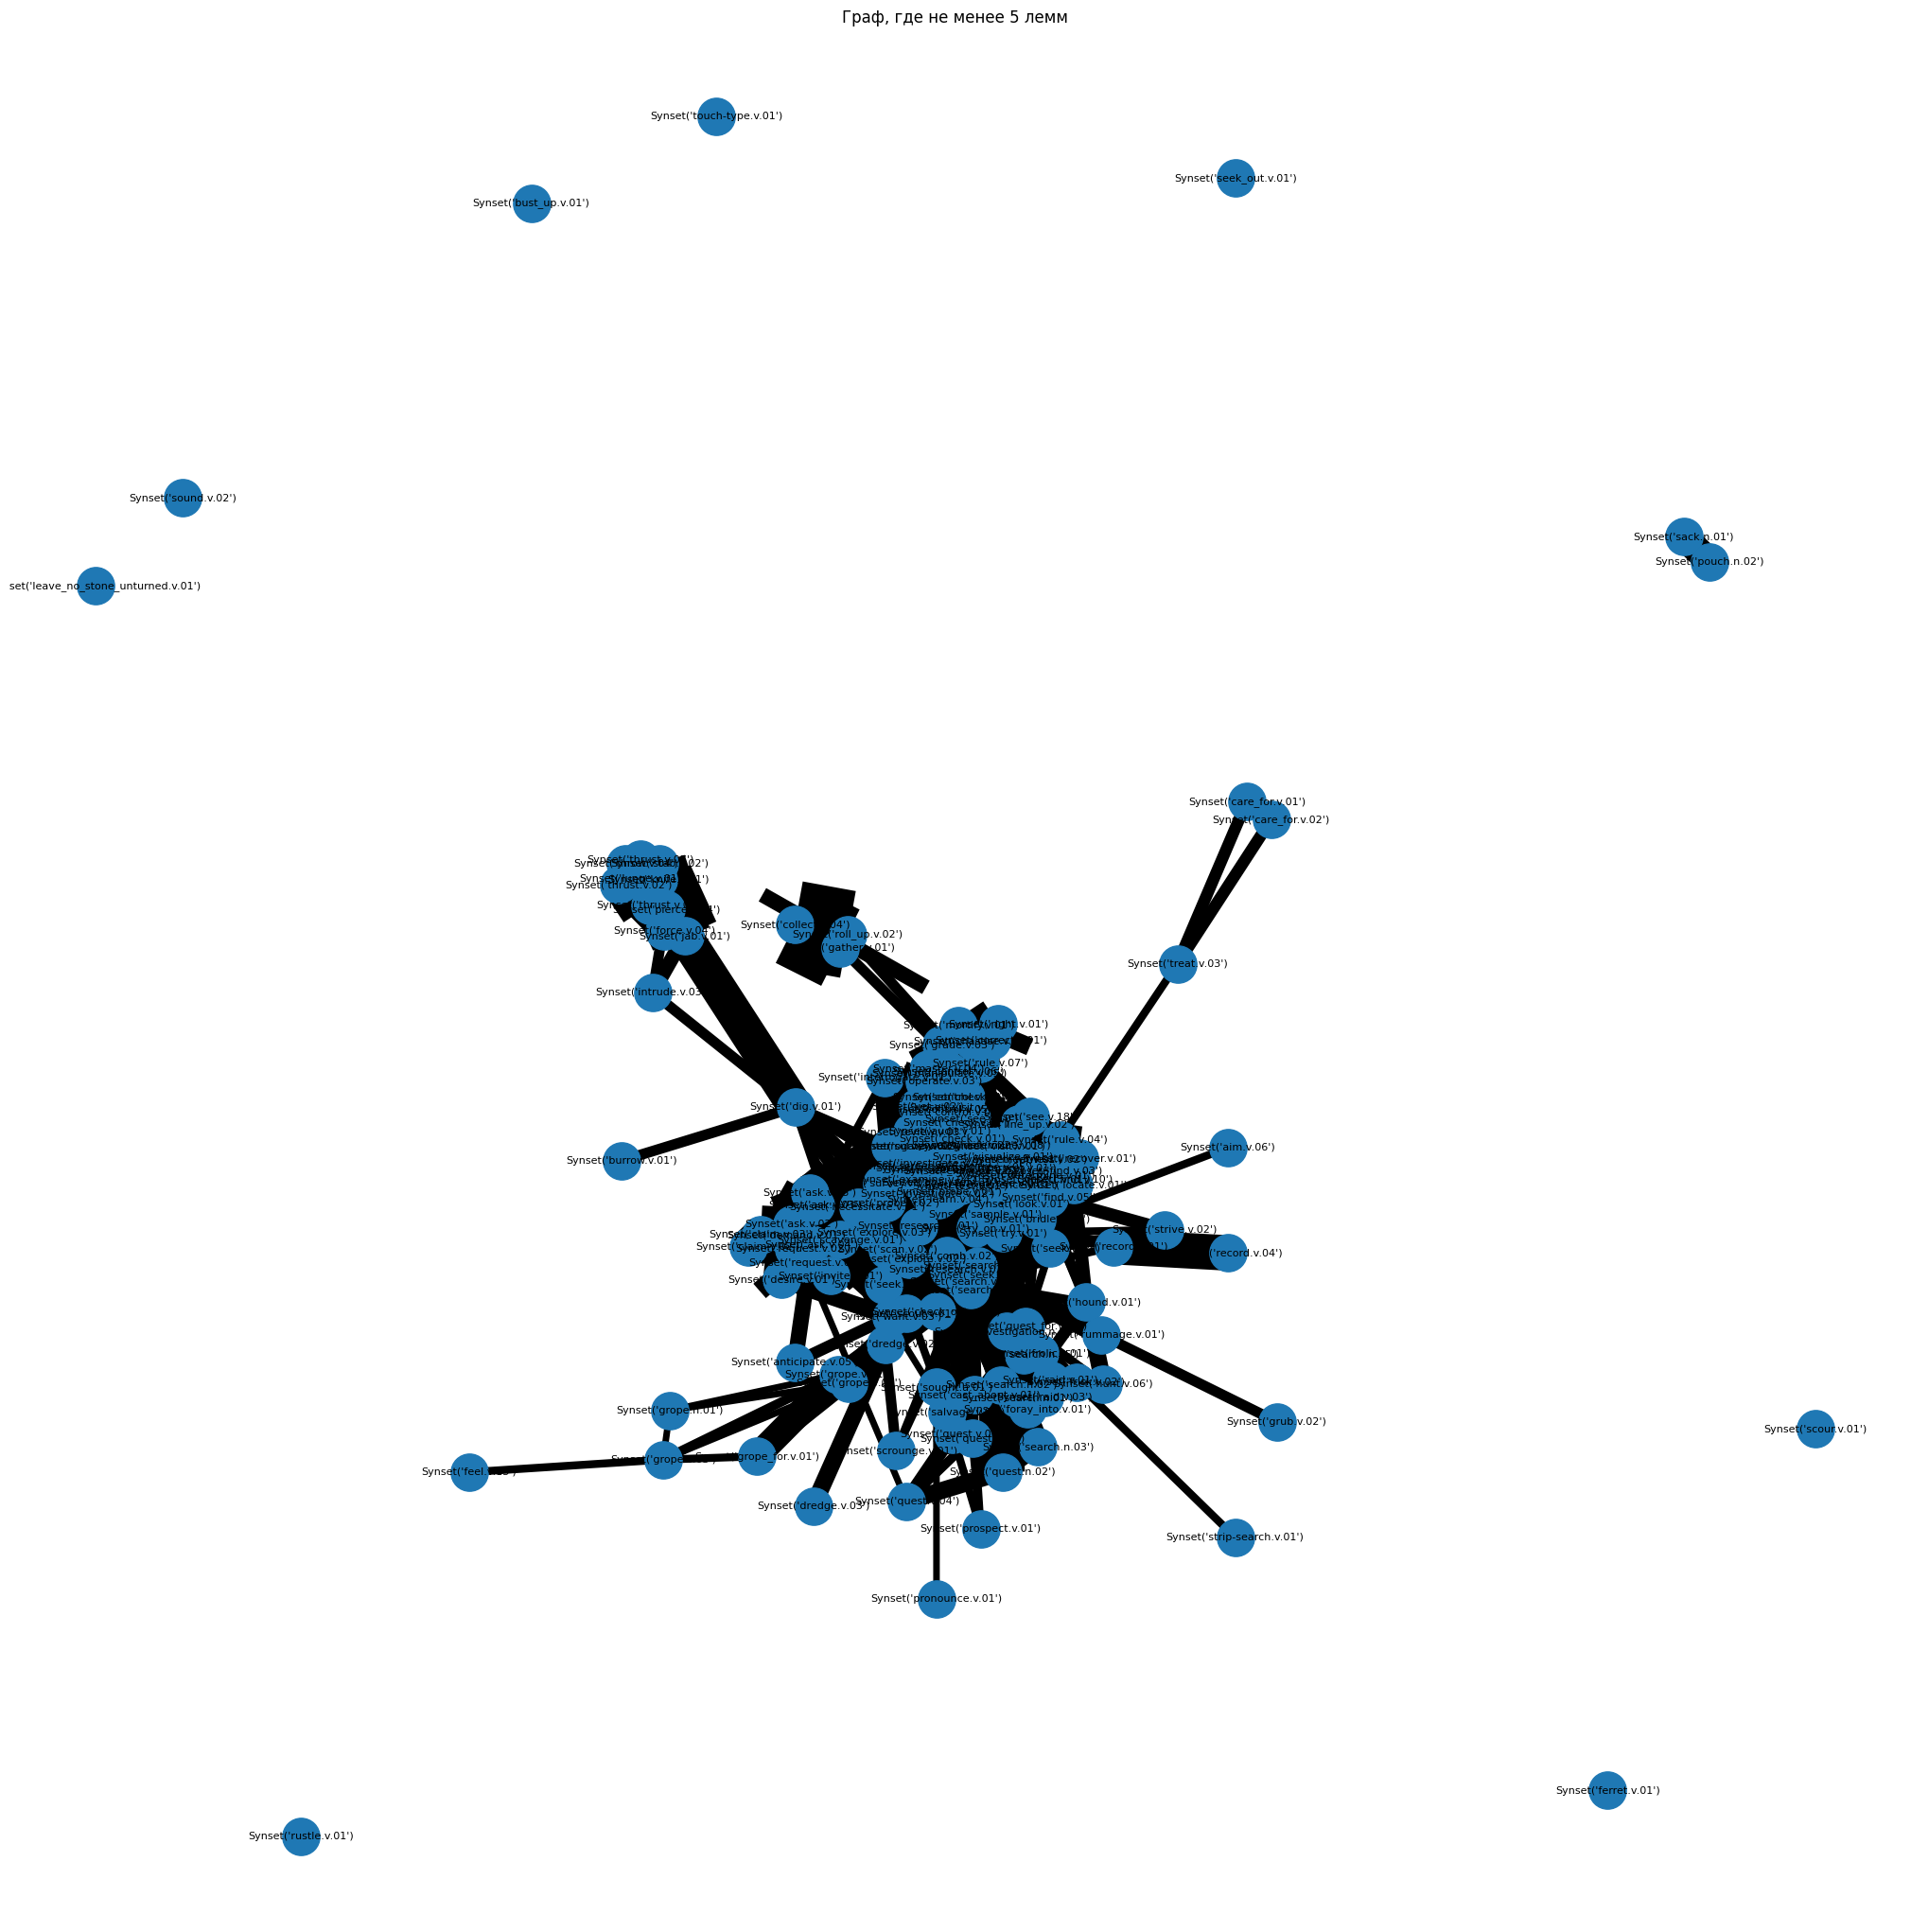

In [107]:
plt.figure(figsize=(20, 20))

pos = nx.spring_layout(G5, k=0.3)

weights = [G5[u][v]['weight'] for u, v in G5.edges()]

nx.draw(
    G5,
    pos,
    with_labels=True,
    node_size=800,
    font_size=8,
    width=weights
)

plt.title("Граф, где не менее 5 лемм")
plt.show()

In [108]:
import numpy as np
import matplotlib.pyplot as plt
from networkx.algorithms import community

H = G5_noiso

# --- компоненты ---
components = list(nx.connected_components(H))
sizes = sorted([len(c) for c in components], reverse=True)
print("Connected components:", len(components))
print("Component sizes:", sizes)

# --- плотность ---
print("Density:", nx.density(H))

# --- степени ---
deg = dict(H.degree())
wdeg = dict(H.degree(weight="weight"))

print("Degree min/mean/max:", np.min(list(deg.values())), np.mean(list(deg.values())), np.max(list(deg.values())))
print("Weighted degree min/mean/max:", np.min(list(wdeg.values())), np.mean(list(wdeg.values())), np.max(list(wdeg.values())))

# --- centrality ---
deg_cent = nx.degree_centrality(H)
close_cent = nx.closeness_centrality(H)
try:
    eig_cent = nx.eigenvector_centrality(H, weight="weight", max_iter=3000)
except nx.PowerIterationFailedConvergence:
    eig_cent = nx.eigenvector_centrality_numpy(H, weight="weight")

def top10(d):
    return sorted(d.items(), key=lambda x: x[1], reverse=True)[:10]

print("\nTop degree centrality:")
for s, c in top10(deg_cent):
    print(s.name(), round(c, 3), "-", s.definition())

print("\nTop closeness centrality:")
for s, c in top10(close_cent):
    print(s.name(), round(c, 3), "-", s.definition())

print("\nTop eigenvector centrality:")
for s, c in top10(eig_cent):
    print(s.name(), round(c, 3), "-", s.definition())


Connected components: 2
Component sizes: [149, 2]
Density: 0.10701986754966887
Degree min/mean/max: 1 16.05298013245033 58
Weighted degree min/mean/max: 5 285.5629139072848 1453

Top degree centrality:
search.v.01 0.387 - try to locate or discover, or try to establish the existence of
determine.v.08 0.353 - find out, learn, or determine with certainty, usually by making an inquiry or other effort
examine.v.02 0.353 - observe, check out, and look over carefully or inspect
search.v.02 0.313 - search or seek
see.v.10 0.307 - be careful or certain to do something; make certain of something
inspect.v.01 0.3 - look over carefully
probe.v.01 0.3 - question or examine thoroughly and closely
analyze.v.01 0.293 - consider in detail and subject to an analysis in order to discover essential features or meaning
research.v.02 0.293 - inquire into
check.v.01 0.287 - examine so as to determine accuracy, quality, or condition

Top closeness centrality:
search.v.01 0.555 - try to locate or discover, or 

In [109]:
from networkx.algorithms import community

H = G5_noiso

# Girvan–Newman (первые 2 уровня)
gn_gen = community.girvan_newman(H)
gn_level1 = next(gn_gen)
gn_level2 = next(gn_gen)

print("GN level 1 sizes:", sorted([len(c) for c in gn_level1], reverse=True))
print("GN level 2 sizes:", sorted([len(c) for c in gn_level2], reverse=True))

# Greedy modularity
com_greedy = list(community.greedy_modularity_communities(H, weight="weight"))
print("Greedy modularity communities:", len(com_greedy))
print("Sizes:", sorted([len(c) for c in com_greedy], reverse=True))

# Показать содержание 2 крупнейших
def describe_community(comm, k=10):
    sub = H.subgraph(list(comm))
    wdeg_sub = dict(sub.degree(weight="weight"))
    top = sorted(wdeg_sub, key=wdeg_sub.get, reverse=True)[:k]
    for s in top:
        print(s.name(), "wdeg_in_comm=", wdeg_sub[s], "-", s.definition())

com_sorted = sorted(com_greedy, key=len, reverse=True)
for i in range(min(2, len(com_sorted))):
    print("\nCommunity", i, "size =", len(com_sorted[i]))
    describe_community(com_sorted[i], k=10)


GN level 1 sizes: [138, 11, 2]
GN level 2 sizes: [135, 11, 3, 2]
Greedy modularity communities: 10
Sizes: [46, 41, 22, 13, 13, 6, 3, 3, 2, 2]

Community 0 size = 46
search.v.01 wdeg_in_comm= 518 - try to locate or discover, or try to establish the existence of
search.v.02 wdeg_in_comm= 457 - search or seek
research.v.02 wdeg_in_comm= 383 - inquire into
search.v.04 wdeg_in_comm= 275 - subject to a search
search.n.02 wdeg_in_comm= 211 - an investigation seeking answers
seek.v.01 wdeg_in_comm= 189 - try to get or reach
search.n.01 wdeg_in_comm= 141 - the activity of looking thoroughly in order to find something or someone
quest.n.02 wdeg_in_comm= 107 - the act of searching for something
grope.v.01 wdeg_in_comm= 105 - feel about uncertainly or blindly
comb.v.02 wdeg_in_comm= 92 - search thoroughly

Community 1 size = 41
control.v.02 wdeg_in_comm= 776 - lessen the intensity of; temper; hold in restraint; hold or keep within limits
see.v.10 wdeg_in_comm= 673 - be careful or certain to do som

##Step 6

What can you say about the colexification patterns in the SEARCH domain based on your graphs?

## Step 7

Compare your results to the subgraph LOOK FOR from CLICS

https://clics.clld.org/parameters/1468#1/21/153

https://clics.clld.org/graphs/SHAVE